In [110]:
import scikitplot as skplt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [111]:
#Loading the dataset
diabetes_data = pd.read_csv('diabetes.csv')

#Print the first 5 rows of the dataframe.
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [112]:
## observing the shape of the data
diabetes_data.shape

(768, 9)

In [113]:
X = diabetes_data.drop("Outcome",axis = 1)
y = diabetes_data.Outcome

In [114]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [115]:
#importing train_test_split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1/3,random_state=42, stratify=y)

`stratify` ensures that class proportions remain consistent with the original dataset in both the training and test sets. This helps avoid issues caused by severe class imbalance and is useful for small-sample classification tasks.

In [116]:
X_train.shape

(512, 8)

In [117]:
X_test.shape

(256, 8)

In [118]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Standardisation must be fitted only on `X_train` to prevent data leakage and simulate inference on genuinely unseen data.

# LOGISTIC REGRESSION

Logistic regression is a supervised model for binary classification. It converts a weighted combination of input features into a probability from 0 to 1, then assigns a class using a threshold. Here, it predicts whether a patient has diabetes.

Parameter $C$ is the inverse of regularisation strength. A very small $C$ can cause underfitting, while a very large $C$ can cause overfitting.

In [119]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(C=0.01).fit(X_train, y_train)
print("Training set score: {:.3f}".format(logreg.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logreg.score(X_test, y_test)))

Training set score: 0.771
Test set score: 0.727


In [120]:
logreg.intercept_.T

array([-0.69624997])

In [121]:
logreg.coef_.T

array([[ 0.21049572],
       [ 0.4711509 ],
       [-0.02096702],
       [-0.00749139],
       [ 0.0892367 ],
       [ 0.29797192],
       [ 0.11138352],
       [ 0.13294067]])

### Confusion Matrix

A confusion matrix summarises results by actual and predicted class, showing true positives, true negatives, false positives, and false negatives to assess false alarms and missed cases.

In [122]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = logreg.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[150  17]
 [ 53  36]]
              precision    recall  f1-score   support

           0       0.74      0.90      0.81       167
           1       0.68      0.40      0.51        89

    accuracy                           0.73       256
   macro avg       0.71      0.65      0.66       256
weighted avg       0.72      0.73      0.71       256



### ROC

The ROC curve shows the true positive rate (TPR) and false positive rate (FPR) across classification thresholds. A larger ROC-AUC generally indicates a stronger ability to distinguish the two classes.

Accuracy= 0.7265625


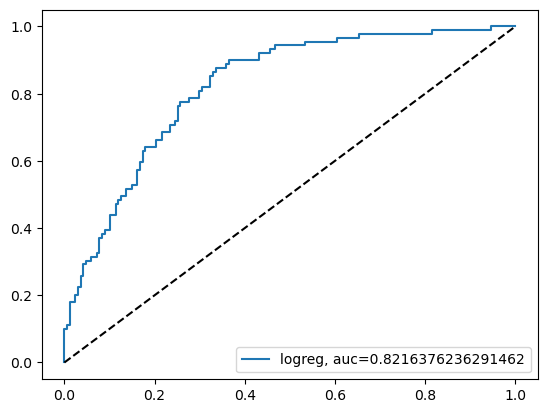

In [123]:
from sklearn import metrics


print("Accuracy=", metrics.accuracy_score(y_test, y_pred))

y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr,tpr,label="logreg, auc="+str(auc))
plt.plot([0,1],[0,1],'k--')
plt.legend(loc=4)
plt.show()

### Gains / Lift Chart

A gains chart measures how many positive cases are covered by the highest-ranked samples ordered by predicted probability. A lift chart compares this ranking with random selection and helps prioritise screening or marketing lists.

In [124]:
y_pred_probas = logreg.predict_proba(X_test)

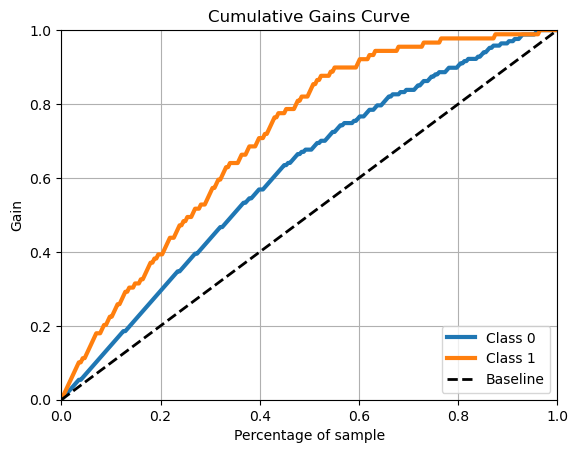

In [125]:
skplt.metrics.plot_cumulative_gain(y_test, y_pred_probas)
plt.show()

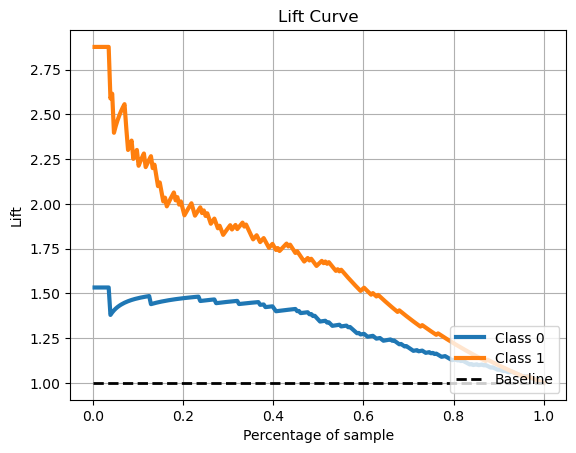

In [126]:
skplt.metrics.plot_lift_curve(y_test, y_pred_probas)
plt.show()

# K-NN

K-Nearest Neighbours (K-NN) is an instance-based classification method. For a new sample, it finds the $k$ nearest training samples in feature space and assigns the class by majority vote.

In [127]:
from sklearn.neighbors import KNeighborsClassifier

test_scores = []
train_scores = []

for i in range(1,15):

    knn = KNeighborsClassifier(i)
    knn.fit(X_train,y_train)

    train_scores.append(knn.score(X_train,y_train))
    test_scores.append(knn.score(X_test,y_test))

In [128]:
## score that comes from testing on the same datapoints that were used for training
max_train_score = max(train_scores)
train_scores_ind = [i for i, v in enumerate(train_scores) if v == max_train_score]
print('Max train score {} % and k = {}'.format(max_train_score*100,list(map(lambda x: x+1, train_scores_ind))))

Max train score 100.0 % and k = [1]


In [129]:
## score that comes from testing on the datapoints that were split in the beginning to be used for testing solely
max_test_score = max(test_scores)
test_scores_ind = [i for i, v in enumerate(test_scores) if v == max_test_score]
print('Max test score {} % and k = {}'.format(max_test_score*100,list(map(lambda x: x+1, test_scores_ind))))

Max test score 76.171875 % and k = [9, 10, 11]


### K-NN Result Visualisation

The chart plots training and test accuracy as $k$ changes. The gap between training and test scores can identify overfitting and support selection of a $k$ value with better generalisation.

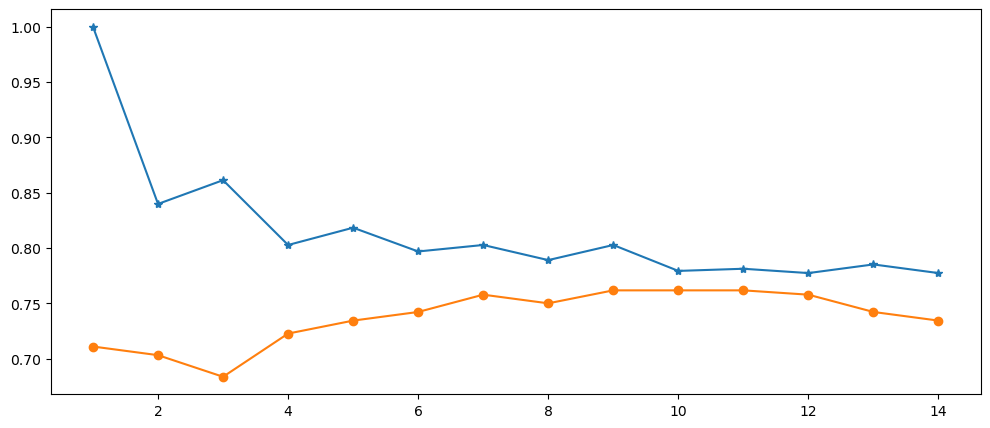

In [130]:
plt.figure(figsize=(12,5))
plt.plot(range(1,15),train_scores,marker='*',label='Train Score')
plt.plot(range(1,15),test_scores,marker='o',label='Test Score')

#### The best result is captured at k = 11 hence 11 is used for the final model

Within the current fixed data split and candidate range, $k=11$ gives the best test performance, so the final K-NN model uses 11 neighbours. In rigorous practice, $k$ should be selected with cross-validation on the training set only.

In [131]:
#Setup a knn classifier with k neighbors
knn = KNeighborsClassifier(11)

knn.fit(X_train,y_train)
knn.score(X_test,y_test)

0.76171875

## Model Performance Analysis

This section evaluates K-NN using a confusion matrix, classification report, ROC curve, and ROC-AUC. Precision, recall, and F1-score reflect prediction accuracy, positive-class detection ability, and the balance between them.

In [132]:
#import confusion_matrix
from sklearn.metrics import confusion_matrix
#let us get the predictions using the classifier we had fit above
y_pred = knn.predict(X_test)
#confusion_matrix(y_test,y_pred)
pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
True,,,
0,145,22,167
1,39,50,89
All,184,72,256


In [133]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83       167
           1       0.69      0.56      0.62        89

    accuracy                           0.76       256
   macro avg       0.74      0.72      0.72       256
weighted avg       0.76      0.76      0.75       256



In [134]:
from sklearn.metrics import roc_curve
y_pred_proba = knn.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

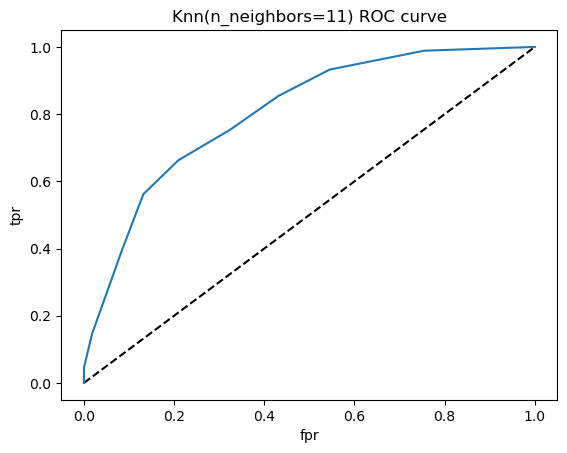

In [135]:
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr,tpr, label='Knn')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('Knn(n_neighbors=11) ROC curve')
plt.show()

In [136]:
#Area under ROC curve
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred_proba)

0.8042454417008679

In [137]:
#import GridSearchCV
from sklearn.model_selection import GridSearchCV
#In case of classifier like knn the parameter to be tuned is n_neighbors
param_grid = {'n_neighbors':np.arange(1,50)}
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X_train,y_train)

print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score:0.7772701313535123
Best Parameters: {'n_neighbors': 19}


### Cross-Validated K-NN Model (k=19)

GridSearchCV selects $k=19$ using five-fold cross-validation on the training set only. The following evaluation keeps the original $k=11$ result and assesses the cross-validated setting once on the held-out test set.

In [138]:
knn_19 = KNeighborsClassifier(n_neighbors=19)
knn_19.fit(X_train, y_train)
y_pred_19 = knn_19.predict(X_test)
y_pred_proba_19 = knn_19.predict_proba(X_test)[:, 1]

print(f'K-NN (k=19) test accuracy: {knn_19.score(X_test, y_test):.3f}')
print(confusion_matrix(y_test, y_pred_19))
print(classification_report(y_test, y_pred_19))
print(f'K-NN (k=19) ROC-AUC: {roc_auc_score(y_test, y_pred_proba_19):.3f}')

K-NN (k=19) test accuracy: 0.738
[[148  19]
 [ 48  41]]
              precision    recall  f1-score   support

           0       0.76      0.89      0.82       167
           1       0.68      0.46      0.55        89

    accuracy                           0.74       256
   macro avg       0.72      0.67      0.68       256
weighted avg       0.73      0.74      0.72       256

K-NN (k=19) ROC-AUC: 0.806


# Naive Bayes

Naive Bayes applies Bayes' theorem to calculate posterior class probabilities and assumes features are conditionally independent given the class. Gaussian Naive Bayes further assumes continuous features approximately follow a Gaussian distribution within each class; it trains quickly and is suitable as a baseline model.

In [139]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

In [140]:
# Initiating the Gaussian Classifier
mod = GaussianNB()

In [141]:
# Training your model
mod.fit(X_train, y_train)

GaussianNB()

In [142]:
# Predicting Outcome
predicted = mod.predict(X_test)

In [143]:
mod.score(X_test,y_test)

0.73828125

In [144]:
# Confusion Matrix
y_pred = mod.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[132  35]
 [ 32  57]]
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       167
           1       0.62      0.64      0.63        89

    accuracy                           0.74       256
   macro avg       0.71      0.72      0.71       256
weighted avg       0.74      0.74      0.74       256



In [145]:
# You can compare the performance of multiple models in one ROC chart. Wrtie your own codes in the cells below.

# Complete Comparative Experiment

,Training Accuracy,Test Accuracy,Precision (Outcome=1),Recall (Outcome=1),F1 Score (Outcome=1),ROC-AUC
Model,,,,,,
Logistic Regression (C=0.01),0.771,0.727,0.679,0.404,0.507,0.822
K-NN (k=11),0.781,0.762,0.694,0.562,0.621,0.804
"K-NN (k=19, cross-validated)",0.777,0.738,0.683,0.461,0.550,0.806
Gaussian Naive Bayes,0.779,0.738,0.620,0.640,0.630,0.796


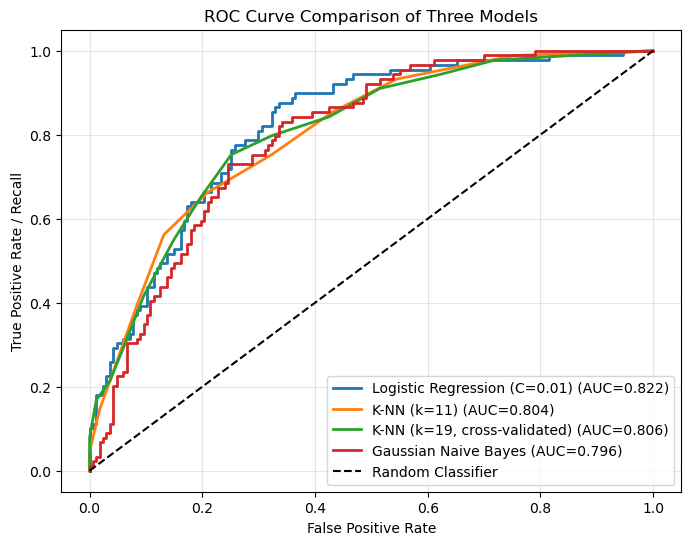

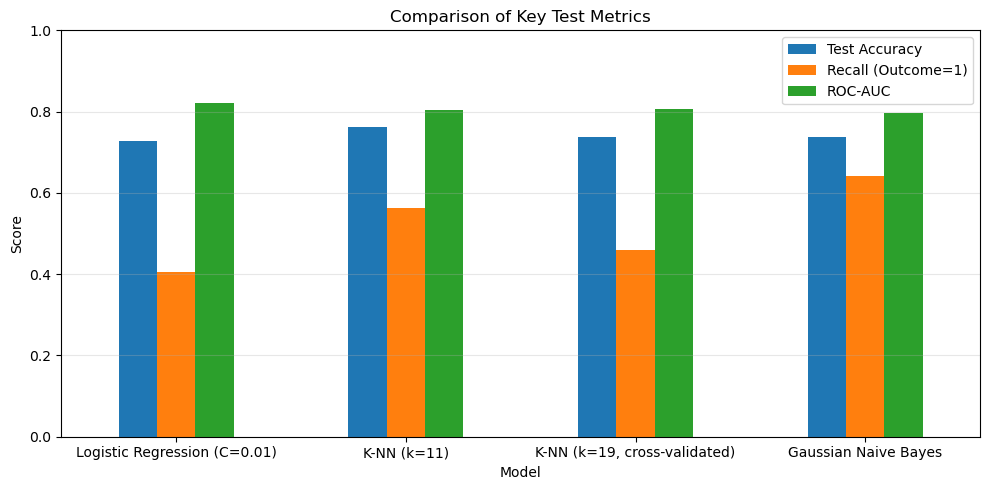

Highest Test Accuracy: K-NN (k=11)
Highest ROC-AUC: Logistic Regression (C=0.01)
Highest Diabetes-Class Recall: Gaussian Naive Bayes


In [146]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from IPython.display import display

models = {
    'Logistic Regression (C=0.01)': LogisticRegression(C=0.01),
    'K-NN (k=11)': KNeighborsClassifier(n_neighbors=11),
    'K-NN (k=19, cross-validated)': KNeighborsClassifier(n_neighbors=19),
    'Gaussian Naive Bayes': GaussianNB()
}

rows = []
probabilities = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]
    probabilities[name] = probability
    rows.append({
        'Model': name,
        'Training Accuracy': model.score(X_train, y_train),
        'Test Accuracy': accuracy_score(y_test, prediction),
        'Precision (Outcome=1)': precision_score(y_test, prediction),
        'Recall (Outcome=1)': recall_score(y_test, prediction),
        'F1 Score (Outcome=1)': f1_score(y_test, prediction),
        'ROC-AUC': roc_auc_score(y_test, probability)
    })

comparison_results = pd.DataFrame(rows).set_index('Model')
display(comparison_results.round(3))

plt.figure(figsize=(8, 6))
for name, probability in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probability)
    auc_value = roc_auc_score(y_test, probability)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc_value:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate / Recall')
plt.title('ROC Curve Comparison of Three Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

comparison_results[['Test Accuracy', 'Recall (Outcome=1)', 'ROC-AUC']].plot(
    kind='bar', figsize=(10, 5), ylim=(0, 1), rot=0
)
plt.ylabel('Score')
plt.title('Comparison of Key Test Metrics')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Highest Test Accuracy:', comparison_results['Test Accuracy'].idxmax())
print('Highest ROC-AUC:', comparison_results['ROC-AUC'].idxmax())
print('Highest Diabetes-Class Recall:', comparison_results['Recall (Outcome=1)'].idxmax())

## Model Comparison and Conclusion

This experiment compares Logistic Regression, two K-NN settings ($k=11$ and cross-validated $k=19$), and Gaussian Naive Bayes using the same training set, test set, and standardised features. This allows performance differences to be attributed to the models rather than to data splitting or preprocessing.

- **Test Accuracy** measures the proportion of all test samples predicted correctly, making it useful for an initial comparison of overall performance.
- **Precision (Outcome=1)** is the proportion of samples predicted as diabetic that actually have diabetes.
- **Recall (Outcome=1)** is the proportion of patients with diabetes that the model identifies successfully. In medical screening, higher recall can reduce missed diagnoses.
- **ROC-AUC** measures how well a model distinguishes the two classes using predicted probabilities; values closer to 1 are better, while 0.5 is close to random guessing.

The table reports both K-NN settings: $k=11$, selected from the fixed test-split experiment, and $k=19$, selected by five-fold cross-validation on the training set. On the held-out test set, $k=11$ achieves higher accuracy, diabetes-class recall, and F1-score, while $k=19$ achieves a marginally higher ROC-AUC. Therefore, $k=11$ is preferred for overall classification performance in this experiment, whereas $k=19$ offers slightly better probability-based ranking. Logistic Regression and Gaussian Naive Bayes remain useful alternatives when ROC-AUC or diabetes-class recall is the priority.